In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/ML_assignment/chest_xray"

print("Dataset path:", DATASET_PATH)
print("Contents:", os.listdir(DATASET_PATH))

Dataset path: /content/drive/MyDrive/ML_assignment/chest_xray
Contents: ['test', 'train', 'val']


In [4]:
for folder in ["train", "test", "val"]:
    folder_path = os.path.join(DATASET_PATH, folder)

    print(f"\n{folder.upper()}")
    print("-" * 30)

    for category in os.listdir(folder_path):
        category_path = os.path.join(folder_path, category)

        if os.path.isdir(category_path):
            print(category, ":", len(os.listdir(category_path)), "images")


TRAIN
------------------------------
PNEUMONIA : 3876 images
NORMAL : 1341 images

TEST
------------------------------
PNEUMONIA : 390 images
NORMAL : 234 images

VAL
------------------------------
NORMAL : 8 images
PNEUMONIA : 8 images


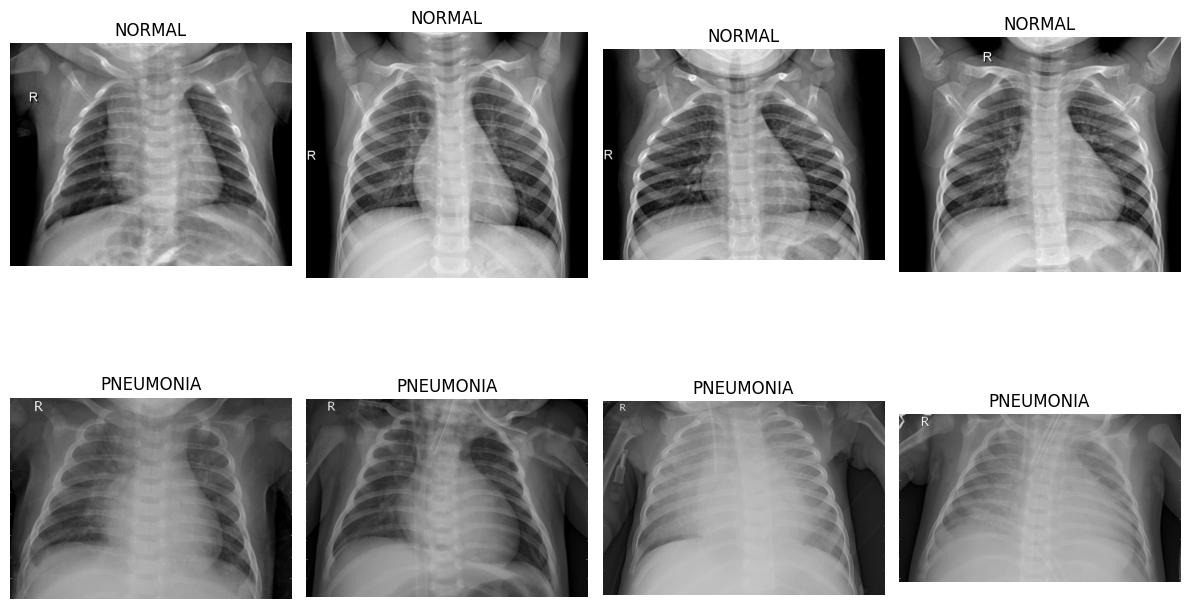

In [5]:
import random
from PIL import Image

categories = ["NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    category_path = os.path.join(DATASET_PATH, "train", category)
    image_files = os.listdir(category_path)

    selected_images = random.sample(image_files, 4)

    for j, image_file in enumerate(selected_images):
        image_path = os.path.join(category_path, image_file)
        image = Image.open(image_path)

        plt.subplot(2, 4, i * 4 + j + 1)
        plt.imshow(image, cmap="gray")
        plt.title(category)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
sample_path = os.path.join(
    DATASET_PATH,
    "train",
    "PNEUMONIA",
    os.listdir(os.path.join(DATASET_PATH, "train", "PNEUMONIA"))[0]
)

sample_image = Image.open(sample_path)

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Image size: (1070, 736)
Image mode: L


In [7]:
for category in categories:
    category_path = os.path.join(DATASET_PATH, "train", category)

    print(f"\n{category}")

    for image_file in os.listdir(category_path)[:10]:
        image_path = os.path.join(category_path, image_file)
        image = Image.open(image_path)

        print(image.size, image.mode)


NORMAL
(1724, 1395) L
(1746, 1392) L
(1604, 1179) L
(1636, 1074) L
(1750, 1314) L
(1458, 1190) L
(1542, 1152) L
(1902, 1595) L
(1426, 1101) L
(1762, 1506) L

PNEUMONIA
(1070, 736) L
(888, 504) L
(992, 656) L
(1068, 763) L
(984, 784) L
(1208, 896) L
(1292, 936) L
(1472, 1176) L
(1306, 844) L
(1712, 1384) L


In [8]:
from PIL import Image

def check_images(folder_path):
    corrupted = []

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                file_path = os.path.join(root, file)

                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except Exception:
                    corrupted.append(file_path)

    return corrupted


for split in ["train", "test", "val"]:
    split_path = os.path.join(DATASET_PATH, split)
    corrupted_files = check_images(split_path)

    print(f"{split.upper()}: {len(corrupted_files)} corrupted images")

    if corrupted_files:
        print(corrupted_files[:5])

TRAIN: 0 corrupted images
TEST: 0 corrupted images
VAL: 0 corrupted images


In [9]:
import pandas as pd

train_path = os.path.join(DATASET_PATH, "train")

image_paths = []
labels = []

for label in ["NORMAL", "PNEUMONIA"]:
    class_path = os.path.join(train_path, label)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, filename))
            labels.append(label)

train_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total training images:", len(train_df))
print("\nClass distribution:")
print(train_df["label"].value_counts())

Total training images: 5217

Class distribution:
label
PNEUMONIA    3876
NORMAL       1341
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

Training images: 4695
Validation images: 522

Training distribution:
label
PNEUMONIA    3488
NORMAL       1207
Name: count, dtype: int64

Validation distribution:
label
PNEUMONIA    388
NORMAL       134
Name: count, dtype: int64


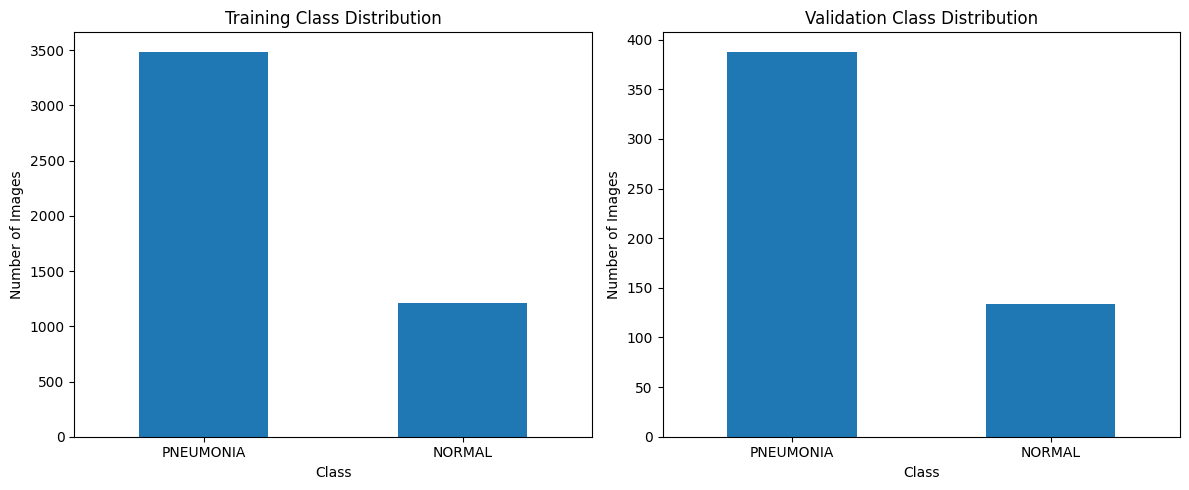

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_df["label"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Training Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=0)

val_df["label"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Validation Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [13]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

label_to_index = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

train_df["label_id"] = train_df["label"].map(label_to_index)
val_df["label_id"] = val_df["label"].map(label_to_index)

print(train_df.head())

                                               filepath      label  label_id
4340  /content/drive/MyDrive/ML_assignment/chest_xra...  PNEUMONIA         1
4039  /content/drive/MyDrive/ML_assignment/chest_xra...  PNEUMONIA         1
3652  /content/drive/MyDrive/ML_assignment/chest_xra...  PNEUMONIA         1
5000  /content/drive/MyDrive/ML_assignment/chest_xra...  PNEUMONIA         1
1553  /content/drive/MyDrive/ML_assignment/chest_xra...  PNEUMONIA         1


In [14]:
def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_jpeg(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [15]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label_id"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label_id"].values
    )
)

train_dataset = (
    train_dataset
    .shuffle(len(train_df), seed=42)
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Datasets created successfully.")

Datasets created successfully.


In [16]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 1.0


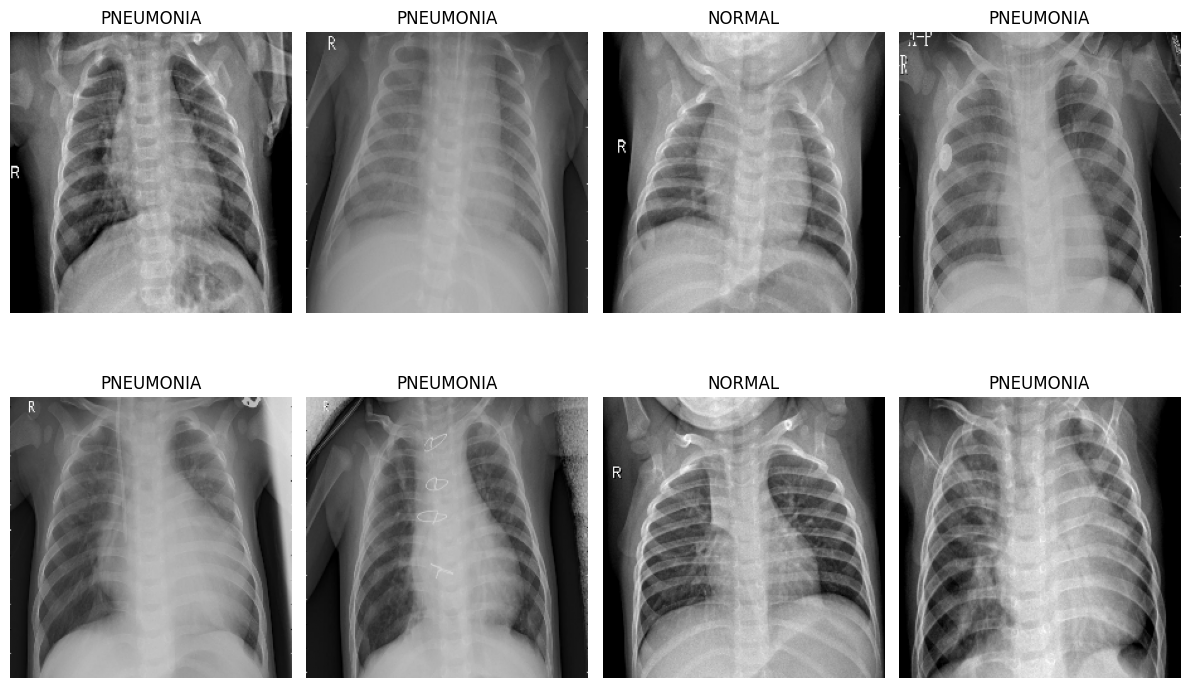

In [17]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        label = CLASS_NAMES[int(labels[i].numpy())]
        plt.title(label)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


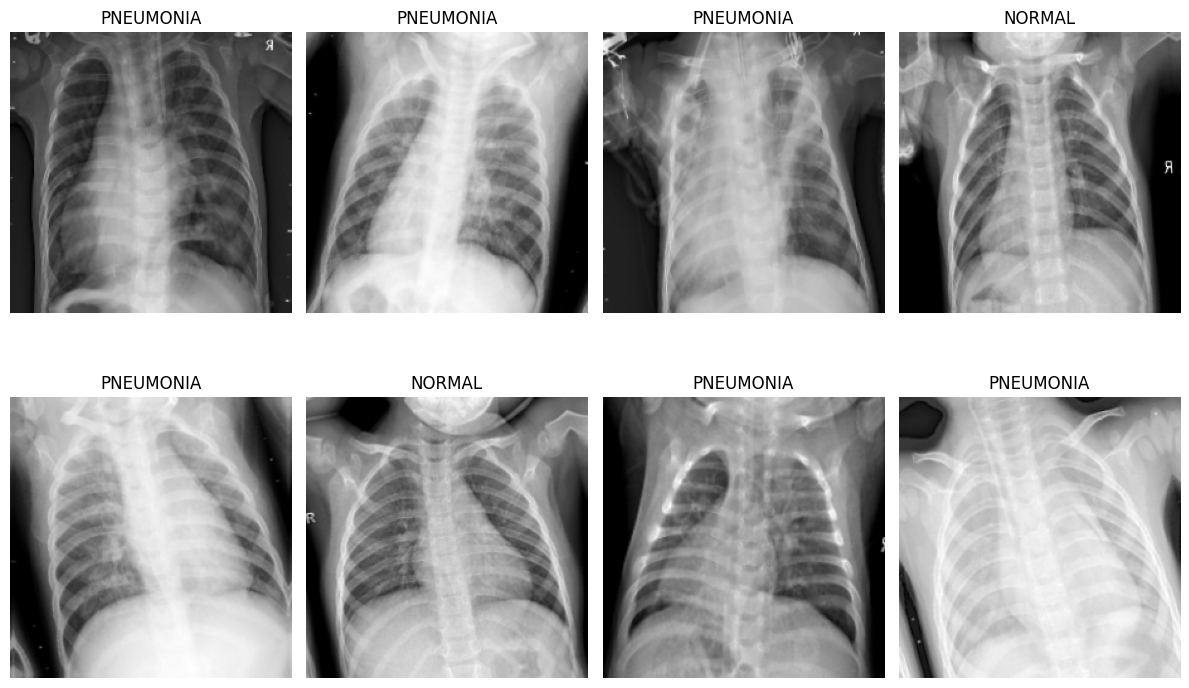

In [19]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images, training=True)

    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(
            augmented_images[i].numpy().squeeze(),
            cmap="gray"
        )
        label = CLASS_NAMES[int(labels[i].numpy())]
        plt.title(label)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"]
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print("Class weights:")
print("NORMAL (0):", class_weights[0])
print("PNEUMONIA (1):", class_weights[1])

Class weights:
NORMAL (0): 1.9449047224523612
PNEUMONIA (1): 0.6730217889908257


In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 1)),

    # Data augmentation
    data_augmentation,

    # CNN blocks
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 43s 254ms/step - accuracy: 0.5216 - loss: 0.6870 - precision: 0.7894 - recall: 0.4857 - val_accuracy: 0.5785 - val_loss: 0.7325 - val_precision: 0.9038 - val_recall: 0.4845
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 33s 225ms/step - accuracy: 0.6345 - loss: 0.6203 - precision: 0.8879 - recall: 0.5814 - val_accuracy: 0.6092 - val_loss: 0.6167 - val_precision: 0.9071 - val_recall: 0.5284
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 39s 215ms/step - accuracy: 0.6319 - loss: 0.5839 - precision: 0.9255 - recall: 0.5487 - val_accuracy: 0.5824 - val_loss: 0.6251 - val_precision: 0.9337 - val_recall: 0.4716
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.6652 - loss: 0.5345 - precision: 0.9456 - recall: 0.5829 - val_accuracy: 0.4617 - val_loss: 0.8394 - val_precision: 0.9908 - val_recall: 0.2784
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 32s 216ms/step - accuracy: 0.7644 - loss: 0.4441 - precision: 0.9437 - recall: 0.7262 - val_accuracy: 0.5134

In [24]:
TEST_PATH = os.path.join(DATASET_PATH, "test")

test_image_paths = []
test_labels = []

for label in ["NORMAL", "PNEUMONIA"]:
    class_path = os.path.join(TEST_PATH, label)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(class_path, filename))
            test_labels.append(label_to_index[label])

test_df = pd.DataFrame({
    "filepath": test_image_paths,
    "label_id": test_labels
})

print("Test images:", len(test_df))
print("\nTest distribution:")
print(test_df["label_id"].map({
    0: "NORMAL",
    1: "PNEUMONIA"
}).value_counts())

Test images: 624

Test distribution:
label_id
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64


In [25]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["filepath"].values,
        test_df["label_id"].values
    )
)

test_dataset = (
    test_dataset
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Test dataset created successfully.")

Test dataset created successfully.


In [26]:
test_results = model.evaluate(test_dataset, verbose=1)

print("\nTest Results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.6234 - loss: 0.6608 - precision: 0.7558 - recall: 0.5872

Test Results:
loss: 0.6608
compile_metrics: 0.6234


In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = []
y_pred_prob = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert probabilities to class predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.4984    0.6838    0.5766       234
   PNEUMONIA     0.7558    0.5872    0.6609       390

    accuracy                         0.6234       624
   macro avg     0.6271    0.6355    0.6187       624
weighted avg     0.6593    0.6234    0.6293       624



Confusion Matrix:
[[160  74]
 [161 229]]


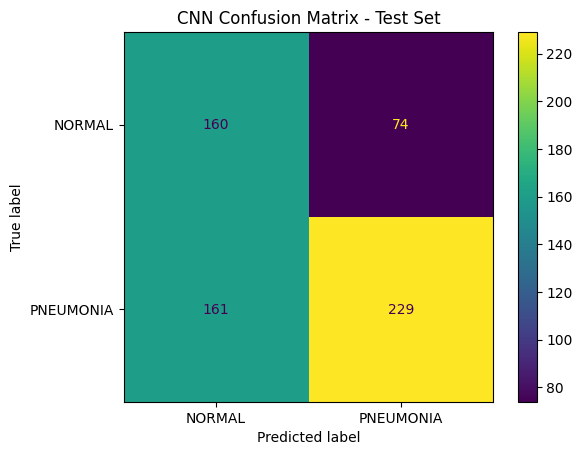

In [28]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("CNN Confusion Matrix - Test Set")
plt.show()

In [29]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.6234
Precision: 0.7558
Recall   : 0.5872
F1-score : 0.6609


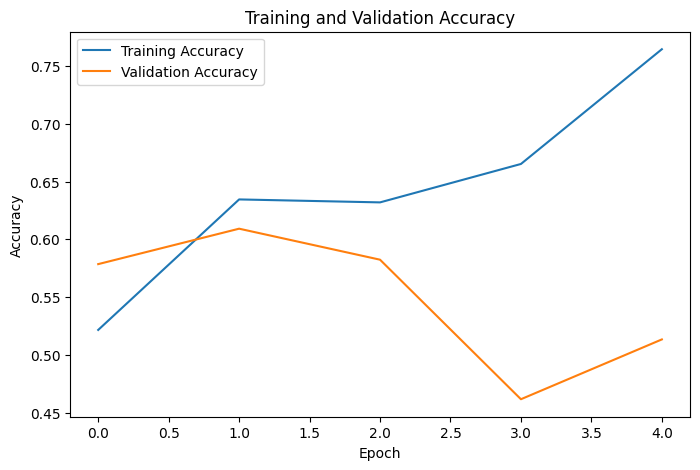

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

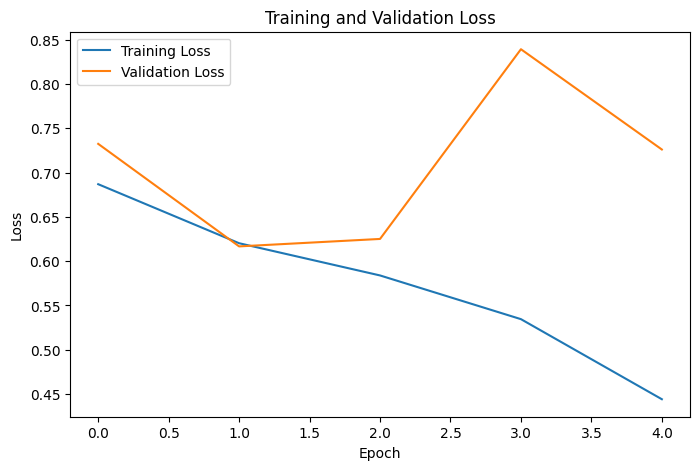

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()